#Final Project Instructions

Few ideas: Regression, Classification, Clustering, PCA
Guidelines:
1. ML framework to be used: Scikit-Learn
2. Visualisation library: matplotlib or seaborn
3. All cells fully executed without error
4. Notebook contents to follow:
- Introduction: The introduction section must include the background of case selection, the data used (amount of data, classes, sources in the form of links), and the objectives to be achieved.
- Import Required Libraries: The first cell in the notebook must contain and only contain all the libraries used in the project.
- Data Loading & Exploratory Data Analysis: This section contains the data loading process, which is then followed by exploratory data analysis (EDA). The EDA process must involve the use of visualization libraries. For example, EDA may include visualizing class distribution in the data, image size distribution (for CV topics), or sentence length distribution (for NLP topics), as well as other necessary data exploration.
- Data Preprocessing: This section contains the process of preparing data for model training, such as splitting the data into train-dev-test, data transformation (normalization, encoding, etc.), and other required processes.
- Model Definition: This section contains the cells for defining the model up to model compilation. It is better if preceded by an explanation of why a certain architecture or model type was chosen, the reasons for selecting specific hyperparameter values, and other related matters.
- Model Training: The cell in this section must only contain code to train the model and the output produced.
- Model Evaluation: In this section, model evaluation must be carried out to show how the model performs based on the chosen metrics. This must be demonstrated with visualizations of performance trends and/or model error rates.
- Model Inference: This section contains model inference, where the trained model will be tested on data other than the available dataset. The data used can be synthetic data created by students or data obtained from the internet.
- Conclusion: In this final chapter, it must contain conclusions that reflect the results obtained compared to the objectives stated in the introduction.

#Machine Learning Project Assessment Rubric:

1	Data Wrangling	Able to perform data loading, initial exploration, and data cleaning using Pandas efficiently and correctly.
2	Exploratory Data Analysis (EDA)	Create at least 5 visualization graphs for data exploration and provide clear insights from these visualizations.
3	Feature Engineering	Perform processes such as feature selection, splitting into train-test, transformation of numerical/categorical data, and appropriate encoding.
4	Modeling	Build at least 2 types of models (e.g., decision tree, logistic regression, etc.), and train the models with appropriate data.
5	Model Evaluation	Determine evaluation metrics that are appropriate for the model type, and calculate those metrics (accuracy, RMSE, F1, etc.).
6	Model Analysis	Provide interpretation of the modeling and evaluation results comprehensively.
7	Code Runs Without Error	All code runs without errors, and main functionalities work correctly.
8	Readability	The notebook is well-documented, using Markdown and comments in the code to explain the analysis flow.
9	Final Conclusion	Provide a summary of the final results of the entire machine learning pipeline in a logical and easy-to-understand manner.

In [150]:
pip install kmodes

Note: you may need to restart the kernel to use updated packages.


In [154]:
# Standard Library & ML Stack Imports
# Core
import os
import math
import json
import warnings
from pathlib import Path
from typing import List, Dict

# I/O & utils
import joblib

# Data handling & visualization
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from wordcloud import WordCloud

# Statistics
from scipy import stats

# Scikit-learn: preprocessing & pipelines
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit
)

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingClassifier

# Scikit-learn: metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    silhouette_score
)

# Scikit-learn: unsupervised
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import load_digits

# k-modes / k-prototypes
try:
    from kmodes.kmodes import KModes
    from kmodes.kprototypes import KPrototypes
except ImportError:
    KModes = KPrototypes = None


In [155]:
# import data, source from: https://www.lottoresults.com/search-results

df_lottery = pd.read_csv("dataset/Tattslotto.csv")
df_lottery.head()

,Draw,Date,1,2,3,4,5,6
0,4601,23/08/2025,2,10,28,33,44,45
1,4599,16/08/2025,1,6,15,18,23,38
2,4597,9/08/2025,4,10,14,40,41,45
3,4595,2/08/2025,1,21,24,40,43,45
4,4593,26/07/2025,2,17,23,40,42,44


In [156]:
#drop "Draw" number column - this is unique column that can be represented by draw date already. Draw number will no be required so it can be dropped
df_lottery = df_lottery.drop(columns=['Draw'])

In [158]:
#change column name so it is easy to differentiate header with contents
df_lottery = df_lottery.rename(columns={
    '1': 'ball_number_1',
    '2': 'ball_number_2',
    '3': 'ball_number_3',
    '4': 'ball_number_4',
    '5': 'ball_number_5',
    '6': 'ball_number_6'
})

In [159]:
#dataset without draw number and with new column header name
df_lottery.head()

,Date,ball_number_1,ball_number_2,ball_number_3,ball_number_4,ball_number_5,ball_number_6
0,23/08/2025,2,10,28,33,44,45
1,16/08/2025,1,6,15,18,23,38
2,9/08/2025,4,10,14,40,41,45
3,2/08/2025,1,21,24,40,43,45
4,26/07/2025,2,17,23,40,42,44


In [160]:
#check the data type
df_lottery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           921 non-null    object
 1   ball_number_1  921 non-null    int64 
 2   ball_number_2  921 non-null    int64 
 3   ball_number_3  921 non-null    int64 
 4   ball_number_4  921 non-null    int64 
 5   ball_number_5  921 non-null    int64 
 6   ball_number_6  921 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 50.5+ KB


The data is already clean - not required further cleaning

In [161]:
#quick inspection on the dataframe, 
print("Shape:", df_lottery.shape) #returns a tuple (rows, columns), i.e. how many records and how many columns are in the dataset.
print("Columns:", list(df_lottery.columns)) #returns the names of the columns. Wrapping it in list() makes it print as a Python list instead of an Index object.

Shape: (921, 7)
Columns: ['Date', 'ball_number_1', 'ball_number_2', 'ball_number_3', 'ball_number_4', 'ball_number_5', 'ball_number_6']


In [162]:
#summary statistics of dataframe’s numeric columns
df_lottery.describe()


,ball_number_1,ball_number_2,ball_number_3,ball_number_4,ball_number_5,ball_number_6
count,921.000000,921.000000,921.000000,921.000000,921.000000,921.000000
mean,6.466884,13.188925,19.768730,26.134636,32.757872,39.334419
std,5.257215,6.754155,7.289043,7.468579,6.973787,5.217758
min,1.000000,2.000000,4.000000,7.000000,9.000000,13.000000
25%,2.000000,8.000000,14.000000,21.000000,28.000000,37.000000
50%,5.000000,12.000000,19.000000,26.000000,34.000000,41.000000
75%,9.000000,18.000000,25.000000,32.000000,38.000000,43.000000
max,30.000000,35.000000,42.000000,43.000000,44.000000,45.000000


## Summary Statistics — Key Takeaways

- **Sample size & completeness:** 921 draws × 6 balls, with counts of 921 for every position ⇒ no missing values.

- **Ordered draws (ascending):** Means and quartiles increase monotonically from `ball_number_1` (mean ≈ 6.47) to `ball_number_6` (mean ≈ 39.33).  
  - This pattern confirms the dataset stores each draw **sorted** from smallest to largest.

- **Spread pattern (order-statistic effect):**  
  - Standard deviation is **largest in the middle positions** (`ball_number_3–4`: ~7.3–7.5) and **smaller at the extremes** (`ball_number_1` and `ball_number_6`: ~5.2).  
  - Intuition: the smallest and largest balls are naturally “pulled” toward the bounds (1 and 45), so they vary less; middle balls can move more freely.

- **Feasible ranges by position:**  
  - Minimums rise with position (e.g., min of `ball_number_1` = 1 vs. `ball_number_6` = 13), and maximums also rise (30 → 45).  
  - Quartiles (25%/50%/75%) step upward roughly evenly across positions, matching the ascending sort.

- **No obvious anomalies:**  
  - Medians (≈ 5, 12, 19, 26, 34, 41) are spaced sensibly; nothing suggests data entry or range errors.


- Because numbers are **sorted per draw**, each column is an **order statistic**, not the same distribution. Avoid comparing columns as if they were i.i.d. samples.  
- To assess fairness or number frequencies, **aggregate all balls across positions** and examine a single 1–45 frequency distribution (e.g., histogram/chi-square test).  
- Complement with: per-position histograms, gap distributions, and correlation between positions to understand structural constraints from sorting.


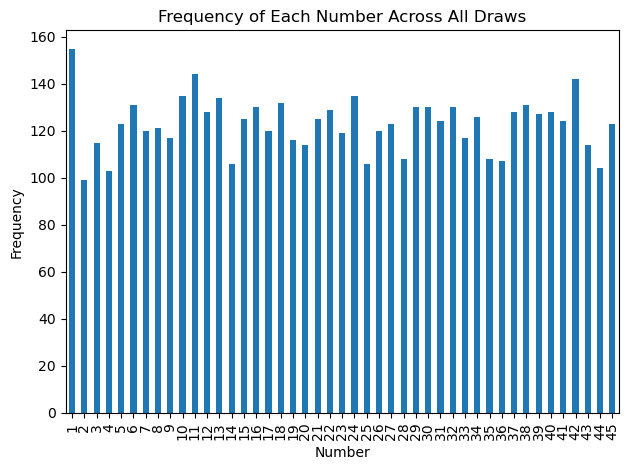

In [163]:
# 1) Frequency of each number across all draws
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]

all_numbers = pd.Series(df_lottery[ball_cols].values.ravel(), name="number")
num_counts = all_numbers.value_counts().sort_index()

plt.figure()
num_counts.plot(kind="bar")
plt.title("Frequency of Each Number Across All Draws")
plt.xlabel("Number")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Insight:** Number frequencies are fairly uniform, as expected in random lottery draws, with minor variation at the edges.

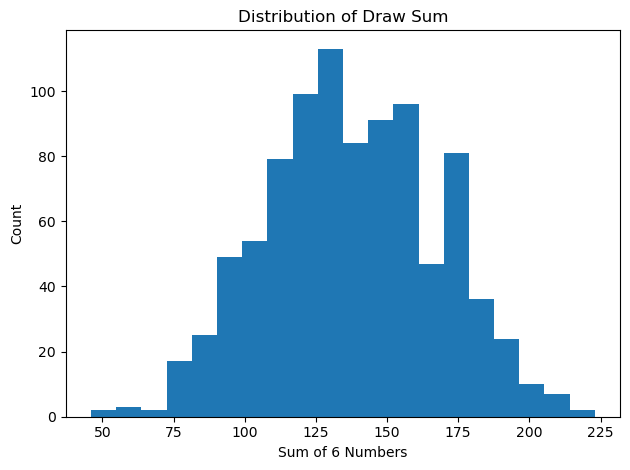

In [164]:
# 2) Distribution of the draw sum

ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]
df_lottery["sum_draw"] = df_lottery[ball_cols].sum(axis=1)

# Plot histogram of sum of balls
plt.figure()
plt.hist(df_lottery["sum_draw"], bins=20)
plt.title("Distribution of Draw Sum")
plt.xlabel("Sum of 6 Numbers")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Distribution of the Draw Sum — Interpretation

- **What the plot shows:** The histogram counts the total of each draw (`sum_draw = ball_1 + … + ball_6`). Because each draw has 6 distinct numbers from 1–45, the sum is naturally **bounded**:
  - **Theoretical min:** 1+2+3+4+5+6 = **21**
  - **Theoretical max:** 40+41+42+43+44+45 = **255**

- **Where it should center:** The mean of numbers 1–45 is (1+45)/2 = **23**, so the expected draw-sum center is **6 × 23 = 138**. In practice, histogram should peak near **≈138** and look roughly **bell-shaped** (CLT effect), tapering toward the hard bounds.

- **Typical shape & spread:** 
  - **Unimodal, approximately symmetric** around ~138.
  - **Thinner tails** near the extremes (≈21 and ≈255) due to the combinatorial constraints (fewer ways to make very small or very large sums).

- **Why this matters:** If we define a classification like **HighSum vs LowSum** using a median (or 138) threshold, the histogram helps confirm that:
  - The classes are **balanced** (near the center).
  - Most probability mass lies near the middle, so features correlated with total (e.g., **mean**, **max**, **min**) will dominate importance.


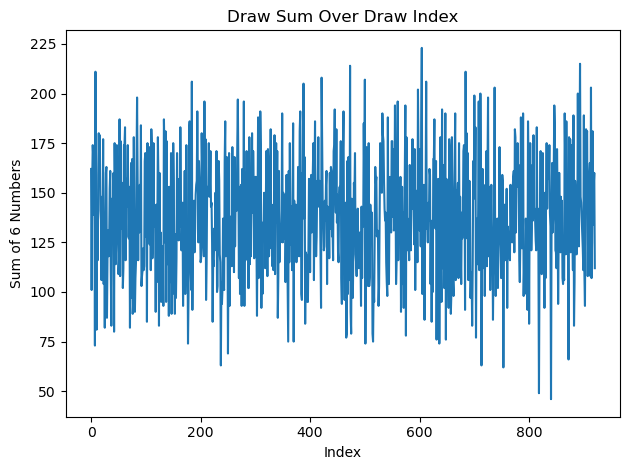

In [165]:
# 3) Draw sum over draw index

# Make sure sum_draw is calculated only from ball_number columns
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]
df_lottery["sum_draw"] = df_lottery[ball_cols].sum(axis=1)

# Plot sum of draws over index
plt.figure()
plt.plot(df_lottery["sum_draw"].values)
plt.title("Draw Sum Over Draw Index")
plt.xlabel("Index")
plt.ylabel("Sum of 6 Numbers")
plt.tight_layout()
plt.show()

## Draw Sum Over Draw Index — Interpretation

- **What this shows:** Each point is the total of one draw (`sum_draw = ball_1 + … + ball_6`) plotted in draw order (by index).
- **Expected behavior:** With fair, independent draws, the series should look like **stationary noise** fluctuating around the long-run mean (~138), with no persistent **trend** or **seasonality**.
- **Range constraints:** Values are bounded between **21** and **255** (theoretical min/max for six distinct numbers from 1–45). Occasional spikes toward the edges are rare but possible.
- **How to read it:**
  - **Centering:** The cloud of points should hover around ~138. Sustained drift away from this may indicate sorting/indexing issues or non-random artifacts.
  - **Volatility:** Fluctuations should be fairly consistent over time. Sudden, lasting changes in spread can hint at data changes (e.g., rule updates, sampling error).
  - **Outliers:** Isolated highs/lows near the bounds are fine; **clusters** of extremes could warrant a data check.


C:\Users\julya\AppData\Local\Temp\ipykernel_32988\1502669515.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_lottery[col] for col in ball_cols], labels=[f"{i}" for i in range(1, len(ball_cols)+1)])


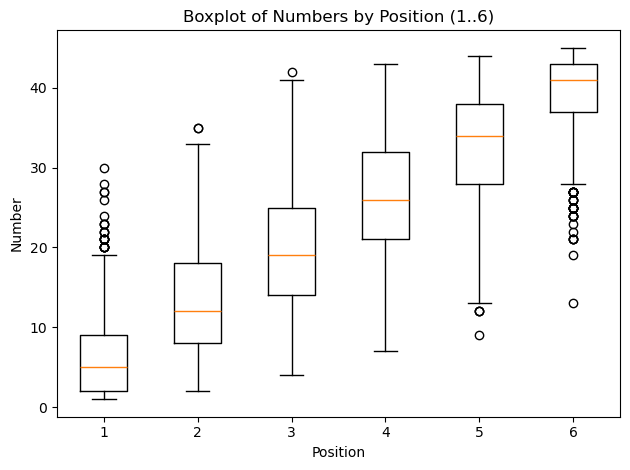

In [166]:
# 4) Boxplot by position
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]

plt.figure()
plt.boxplot([df_lottery[col] for col in ball_cols], labels=[f"{i}" for i in range(1, len(ball_cols)+1)])
plt.title("Boxplot of Numbers by Position (1..6)")
plt.xlabel("Position")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

## Boxplot of Numbers by Position (1..6) — Interpretation

- **Ascending order by design:** Medians rise smoothly from position **1 → 6**, confirming each draw is stored **sorted** (smallest to largest).
- **Spread pattern (order-statistic effect):**  
  - **Narrower IQR/whiskers** at the extremes (positions **1** and **6**) — these are “pulled” toward bounds (1 and 45).  
  - **Wider IQR** in the middle positions (**3–4**), which have the most freedom to vary.
- **Whiskers & skew:** Lower positions show longer **upper** whiskers; higher positions show longer **lower** whiskers, reflecting asymmetric room to move within bounds.
- **Outliers:** Few, as the sampling space is constrained; isolated points just indicate rare combinations near the limits.

### Why it matters
- Each column is an **order statistic**, not identically distributed. Avoid treating positions as interchangeable features.
- For modeling, consider either:
  - Using the raw **sorted positions** as positional features, or  
  - Transforming to **order-invariant features** (gaps, min/max, range, mean) depending on the task.


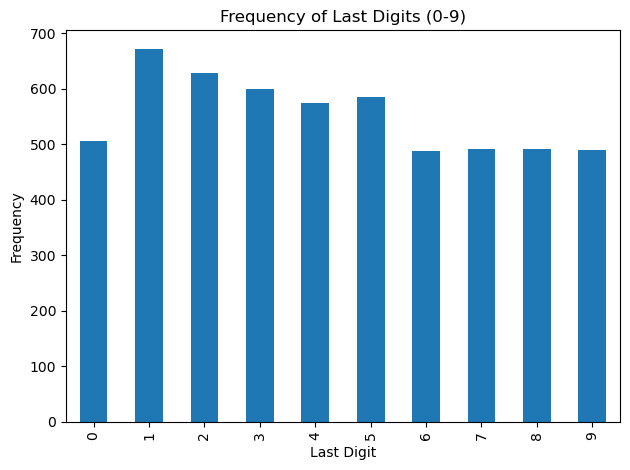

In [168]:
# 5) Frequency of last digits (0-9)

# Collect all ball columns
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]

# Flatten all ball numbers into one Series
all_numbers = pd.Series(df_lottery[ball_cols].values.ravel(), name="number")

# Compute last digits
last_digits = all_numbers.astype(int) % 10
ld_counts = last_digits.value_counts().sort_index()

# Plot frequency of last digits
plt.figure()
ld_counts.plot(kind="bar")
plt.title("Frequency of Last Digits (0-9)")
plt.xlabel("Last Digit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Frequency of Last Digits (0–9) — Interpretation

- **What’s measured:** in every drawn number (across all positions), compute its **last digit** (`n % 10`), and count how often each 0–9 digit appears.

- **Expected baseline (1–45):** In the pool 1…45, last digits are **not perfectly uniform**:
  - Digits **1–5** occur **5 times each** → ≈ **11.1%** each (e.g., 1,11,21,31,41).
  - Digits **0,6,7,8,9** occur **4 times each** → ≈ **8.9%** each (e.g., 10,20,30,40 for 0).
  - Over many random draws (without replacement per draw), the histogram should trend toward these ratios.

- **How to read the bars:**
  - Bars for **1–5** should be **slightly taller** than those for **0,6–9**.
  - Small deviations from the expected 11.1% vs 8.9% split are normal sampling noise.


Using columns: ['ball_number_1', 'ball_number_2', 'ball_number_3', 'ball_number_4', 'ball_number_5', 'ball_number_6']
Total numbers collected: 5526


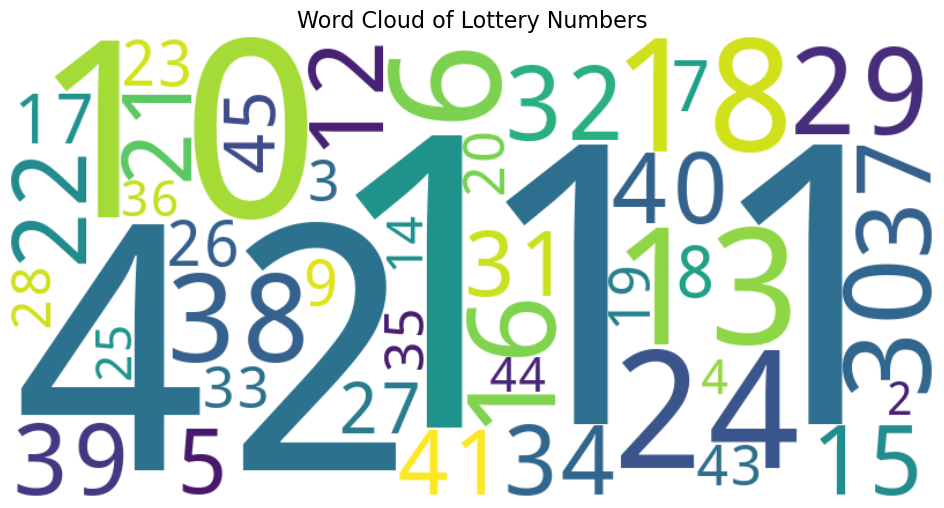

In [ ]:
# === Word Cloud of Lottery Numbers (robust, uses frequencies) ===

# Pick the right DataFrame
_df = None
for cand in ["df_lottery", "df"]:
    if cand in globals():
        _df = globals()[cand]
        break
if _df is None:
    raise RuntimeError("No dataframe named df_lottery or df found.")

# Identify ball columns
ball_cols = [c for c in _df.columns if str(c).startswith("ball_number_")]
if not ball_cols:
    # Fallback: try original numeric names '1'..'6'
    candidate = [str(i) for i in range(1, 7)]
    if all(c in _df.columns for c in candidate):
        ball_cols = candidate

if not ball_cols:
    raise RuntimeError("Could not find ball columns. Found columns: " + ", ".join(map(str, _df.columns)))

# Flatten numbers and compute frequencies
all_nums = _df[ball_cols].to_numpy().ravel()
all_nums = all_nums[~pd.isna(all_nums)]  # drop NaNs if any
all_nums = all_nums.astype(int)

print(f"Using columns: {ball_cols}")
print(f"Total numbers collected: {len(all_nums)}")

if len(all_nums) == 0:
    raise RuntimeError("No numbers found in the selected columns.")

freq = pd.Series(all_nums).value_counts().sort_index().astype(int).to_dict()
# keys must be strings for nicer display
freq_str = {str(k): int(v) for k, v in freq.items()}

# Generate from frequencies (avoids empty-text issues)
wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis")
wc = wc.generate_from_frequencies(freq_str)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Lottery Numbers", fontsize=16)
plt.show()

## Word Cloud of Lottery Numbers — Interpretation

- **What it shows:** Each number’s **font size** reflects how often it appears across all draws and positions (frequencies aggregated over the selected `ball_number_*` columns).

- **Expected baseline (fair draws 1–45):** Over a large sample, frequencies should be **approximately uniform**. Minor differences are normal due to randomness.

In [171]:
# === Data Preprocessing & Feature Engineering ===

#how many of the drawn balls are prime numbers.
def primes_upto(n: int) -> List[int]:
    sieve = np.ones(n+1, dtype=bool)
    sieve[0:2] = False
    for p in range(2, int(np.sqrt(n))+1):
        if sieve[p]:
            sieve[p*p:n+1:p] = False
    return list(np.where(sieve)[0])

# Find all prime numbers up to the max ball value
PRIMES = set(primes_upto(int(df_lottery.filter(like="ball_number_").values.max())))
def engineer_features(row: pd.Series) -> Dict[str, float]:
    nums = np.sort(row.values.astype(int))
    diffs = np.diff(nums)
    f: Dict[str, float] = {
        # compute sum separately for targets
        "mean": nums.mean(),
        "std": np.std(nums, ddof=1),
        "min": nums.min(),
        "max": nums.max(),
        "range": nums.max() - nums.min(),
        "odd_count": int(np.sum(nums % 2 == 1)),
        "even_count": int(np.sum(nums % 2 == 0)),
        "consecutive_pairs": int(np.sum(diffs == 1)),
        "mean_gap": float(diffs.mean()),
        "max_gap": int(diffs.max()),
        "prime_count": int(np.sum([n in PRIMES for n in nums])),
    }
    # last digit composition
    for d in range(10):
        f[f"ld_{d}"] = int(np.sum(nums % 10 == d))
    return f

# Build feature matrix from the ball_number columns
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]
feature_df = df_lottery[ball_cols].apply(engineer_features, axis=1, result_type="expand")
display(feature_df.head())

,mean,std,min,max,range,odd_count,even_count,consecutive_pairs,mean_gap,max_gap,...,ld_0,ld_1,ld_2,ld_3,ld_4,ld_5,ld_6,ld_7,ld_8,ld_9
0,27.000000,17.686153,2.0,45.0,43.0,2.0,4.0,1.0,8.6,18.0,...,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
1,16.833333,13.105978,1.0,38.0,37.0,3.0,3.0,0.0,7.4,15.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,0.0
2,25.666667,18.250114,4.0,45.0,41.0,2.0,4.0,1.0,8.2,26.0,...,2.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
3,29.000000,17.005881,1.0,45.0,44.0,4.0,2.0,0.0,8.8,20.0,...,1.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,28.000000,16.840428,2.0,44.0,42.0,2.0,4.0,0.0,8.4,17.0,...,1.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


## Data Preprocessing Summary

**What the code does**
- Builds a reusable **prime sieve** (`primes_upto`) and a set `PRIMES` up to the maximum ball value in the data.
- Defines `engineer_features(row)` that converts one sorted 6-number draw into a rich, order-invariant feature vector.
- Applies this function across all `ball_number_*` columns to create `feature_df`, the model-ready feature matrix.

**Features created (per draw)**
- **Central tendency & spread:**  
  - `mean` (dominant proxy for total)  
  - `std` (dispersion of the six numbers)
- **Extremes & range:**  
  - `min`, `max`, `range`
- **Parity composition:**  
  - `odd_count`, `even_count`
- **Local structure:**  
  - `consecutive_pairs` (how many adjacent numbers differ by 1)  
  - `mean_gap`, `max_gap` (from the sorted differences)
- **Primality:**  
  - `prime_count` (# of primes among the six numbers)
- **Last-digit composition (0–9):**  
  - `ld_0 … ld_9` (counts per last digit)


In [172]:
#====This section prepares the targets and splits the data so it can train, validate, and test the ML models properly.

#Define machine learning targets and then split the data for training, validation (dev), and testing.

# Targets
y_sum = df_lottery[ball_cols].sum(axis=1).astype(float)
y_class = (y_sum >= y_sum.median()).astype(int)  # HighSum class

# Time-based split 70/15/15
n = len(feature_df)
train_end = int(0.70 * n)
dev_end = int(0.85 * n)

X_train = feature_df.iloc[:train_end].copy()
X_dev   = feature_df.iloc[train_end:dev_end].copy()
X_test  = feature_df.iloc[dev_end:].copy()

y_train_c = y_class.iloc[:train_end]
y_dev_c   = y_class.iloc[train_end:dev_end]
y_test_c  = y_class.iloc[dev_end:]

y_train_r = y_sum.iloc[:train_end]
y_dev_r   = y_sum.iloc[train_end:dev_end]
y_test_r  = y_sum.iloc[dev_end:]

print({"train": len(X_train), "dev": len(X_dev), "test": len(X_test)})


{'train': 644, 'dev': 138, 'test': 139}


In [174]:
# === Model Definition ===
# This code sets up three classification models and three regression models:
# Logistic Regression, Random Forest, and Decision Tree for classification
# Linear Regression, Random Forest Regressor, and Decision Tree Regressor for regression


# -----------------
# Classification
# -----------------
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

clf_rf = Pipeline([
    # Trees don't need scaling
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

#Decision Tree (Classifier)
clf_dt = Pipeline([
    # Trees don't need scaling
    ("model", DecisionTreeClassifier(
        random_state=42,
        # tweakables:
        # max_depth=None,
        # min_samples_split=2,
        # min_samples_leaf=1,
        # criterion="gini"
    ))
])

# -----------------
# Regression
# -----------------
reg_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

reg_rf = Pipeline([
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

#Decision Tree (Regressor)
reg_dt = Pipeline([
    ("model", DecisionTreeRegressor(
        random_state=42,
        # tweakables:
        # max_depth=None,
        # min_samples_split=2,
        # min_samples_leaf=1,
        # criterion="squared_error"
    ))
])

print("Models defined: "
      "Classification -> Logistic Regression, Random Forest, Decision Tree; "
      "Regression -> Linear Regression, Random Forest Regressor, Decision Tree Regressor.")

# registries to make training loops easier
classifiers = {
    "LogisticRegression": clf_lr,
    "RandomForest": clf_rf,
    "DecisionTree": clf_dt
}

regressors = {
    "LinearRegression": reg_lr,
    "RandomForestRegressor": reg_rf,
    "DecisionTreeRegressor": reg_dt
}

Models defined: Classification -> Logistic Regression, Random Forest, Decision Tree; Regression -> Linear Regression, Random Forest Regressor, Decision Tree Regressor.


In [175]:
# === Full Model Definition + Training + Results (incl. Decision Trees, safe alignment) ===

# ---------------------------
# 0) Safety checks & helpers
# ---------------------------
required_vars = ["X_train", "y_train_c", "y_train_r"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. "
                    "You must define X_train, y_train_c (classification), y_train_r (regression) before this block.")

def _align_xy(X, y):
    """
    Align X and y to the same samples.
    - If both are pandas with indices, align on intersection.
    - Otherwise, truncate to the minimum length.
    """
    is_pd_X = hasattr(X, "iloc") and hasattr(X, "index")
    is_pd_y = hasattr(y, "iloc") and hasattr(y, "index")

    if is_pd_X and is_pd_y:
        idx = X.index.intersection(y.index)
        if len(idx) == 0:
            raise ValueError("No overlapping indices between X and y.")
        return X.loc[idx], y.loc[idx]

    n = min(len(X), len(y))
    return X[:n], y[:n]

def _safe_auc(y_true, proba):
    """Robust ROC-AUC for binary/multiclass; returns NaN if not applicable."""
    try:
        proba = np.asarray(proba)
        if proba.ndim == 1:
            return roc_auc_score(y_true, proba)
        if proba.shape[1] == 2:
            return roc_auc_score(y_true, proba[:, 1])
        return roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")
    except Exception:
        return np.nan

def _get_test_split(X_tr, y_tr, task="classification"):
    """
    Return (X_test, y_test) aligned if they exist; otherwise fall back to (X_tr, y_tr).
    For classification, expects y_test_c; for regression, y_test_r.
    """
    if task == "classification" and "X_test" in globals() and "y_test_c" in globals():
        return _align_xy(X_test, y_test_c)
    if task == "regression" and "X_test" in globals() and "y_test_r" in globals():
        return _align_xy(X_test, y_test_r)
    # Fallback to training split if test not provided
    return X_tr, y_tr

# ---------------------------------
# 1) Define models (incl. DTs)
# ---------------------------------
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

clf_rf = Pipeline([
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

clf_dt = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

reg_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

reg_rf = Pipeline([
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

reg_dt = Pipeline([
    ("model", DecisionTreeRegressor(random_state=42))
])

# ---------------------------------
# 2) Align splits per task
# ---------------------------------
# Classification
X_train_c_al, y_train_c_al = _align_xy(X_train, y_train_c)
X_test_c_al, y_test_c_al   = _get_test_split(X_train_c_al, y_train_c_al, task="classification")

# Regression
X_train_r_al, y_train_r_al = _align_xy(X_train, y_train_r)
X_test_r_al, y_test_r_al   = _get_test_split(X_train_r_al, y_train_r_al, task="regression")

print(f"[classification] train={len(y_train_c_al)} test={len(y_test_c_al)}")
print(f"[regression]    train={len(y_train_r_al)} test={len(y_test_r_al)}")

# ---------------------------------
# 3) Train + evaluate; update `results`
# ---------------------------------
results = globals().get("results", {})  # reuse if it already exists

# 3A) Classification models
classifiers = {
    "LogisticRegression": clf_lr,
    "RandomForest": clf_rf,
    "DecisionTree": clf_dt
}

for name, pipe in classifiers.items():
    pipe.fit(X_train_c_al, y_train_c_al)

    # Dev (train) metrics
    y_dev_pred = pipe.predict(X_train_c_al)
    dev_f1 = f1_score(y_train_c_al, y_dev_pred, average="weighted")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dev_auc = _safe_auc(y_train_c_al,
                            pipe.predict_proba(X_train_c_al) if hasattr(pipe, "predict_proba") else np.nan)

    # Test metrics
    y_tst_pred = pipe.predict(X_test_c_al)
    tst_f1 = f1_score(y_test_c_al, y_tst_pred, average="weighted")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        tst_auc = _safe_auc(y_test_c_al,
                            pipe.predict_proba(X_test_c_al) if hasattr(pipe, "predict_proba") else np.nan)

    results[name] = {
        "Dev":  {"f1": float(dev_f1), "roc_auc": float(dev_auc) if not np.isnan(dev_auc) else np.nan},
        "Test": {"f1": float(tst_f1), "roc_auc": float(tst_auc) if not np.isnan(tst_auc) else np.nan},
    }
    print(f"[trained] {name} (Classifier)")

# 3B) Regression models
regressors = {
    "LinearRegression": reg_lr,
    "RandomForestRegressor": reg_rf,
    "DecisionTreeRegressor": reg_dt
}

for name, pipe in regressors.items():
    pipe.fit(X_train_r_al, y_train_r_al)

    # Dev (train) metrics
    y_dev_pred = pipe.predict(X_train_r_al)
    dev_rmse = float(np.sqrt(mean_squared_error(y_train_r_al, y_dev_pred)))
    dev_r2   = float(r2_score(y_train_r_al, y_dev_pred))

    # Test metrics
    y_tst_pred = pipe.predict(X_test_r_al)
    tst_rmse = float(np.sqrt(mean_squared_error(y_test_r_al, y_tst_pred)))
    tst_r2   = float(r2_score(y_test_r_al, y_tst_pred))

    results[name] = {
        "Dev":  {"RMSE": dev_rmse, "R2": dev_r2},
        "Test": {"RMSE": tst_rmse, "R2": tst_r2},
    }
    print(f"[trained] {name} (Regressor)")

# Keep results available to later cells
globals()["results"] = results

print("\nAll models trained and `results` updated with:")
print(", ".join(results.keys()))

[classification] train=644 test=139
[regression]    train=644 test=139
[trained] LogisticRegression (Classifier)
[trained] RandomForest (Classifier)
[trained] DecisionTree (Classifier)
[trained] LinearRegression (Regressor)
[trained] RandomForestRegressor (Regressor)
[trained] DecisionTreeRegressor (Regressor)

All models trained and `results` updated with:
LogisticRegression, RandomForest, DecisionTree, LinearRegression, RandomForestRegressor, DecisionTreeRegressor



Classification (LogisticRegression):
{
  "Train": {
    "accuracy": 0.9860248447204969,
    "precision": 0.9850299401197605,
    "recall": 0.987987987987988,
    "f1": 0.9865067466266867,
    "roc_auc": 0.9994785782567133
  },
  "Dev": {
    "accuracy": 0.9710144927536232,
    "precision": 0.9848484848484849,
    "recall": 0.9558823529411765,
    "f1": 0.9701492537313433,
    "roc_auc": 0.9976890756302521
  },
  "Test": {
    "accuracy": 0.9136690647482014,
    "precision": 0.9117647058823529,
    "recall": 0.9117647058823529,
    "f1": 0.9117647058823529,
    "roc_auc": 0.9913007456503727
  }
}

Classification (RandomForest):
{
  "Train": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0
  },
  "Dev": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0
  },
  "Test": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0
  }
}

Classification (Decis

<Figure size 640x480 with 0 Axes>

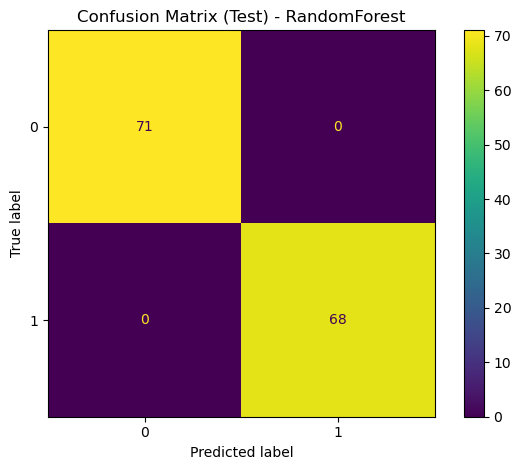

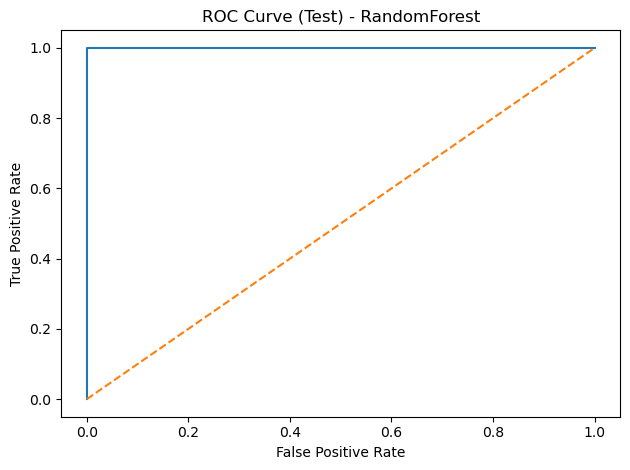

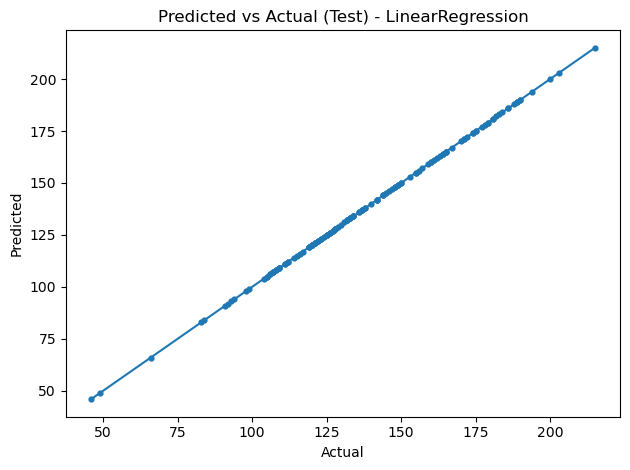

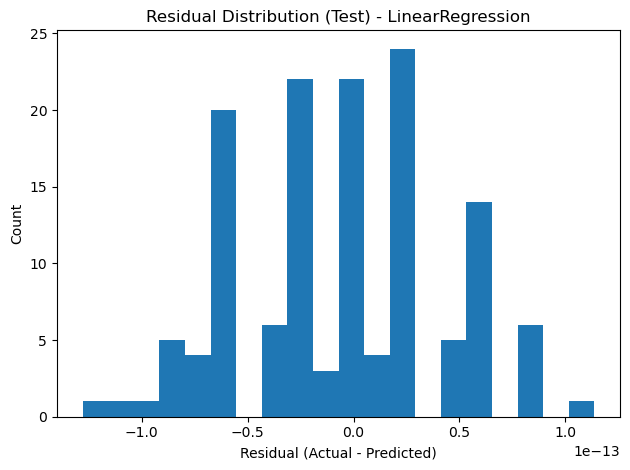

In [177]:
# === Model Evaluation (merged; includes Decision Tree) ===

# 1) Ensure DT models exist (or define defaults)
try:
    clf_dt
except NameError:
    clf_dt = Pipeline([("model", DecisionTreeClassifier(random_state=42))])

try:
    reg_dt
except NameError:
    reg_dt = Pipeline([("model", DecisionTreeRegressor(random_state=42))])

# 2) Helpers: align rows AND enforce same columns/order as train
def _align_xy(X, y, name=""):
    is_pd_X = hasattr(X, "iloc") and hasattr(X, "index")
    is_pd_y = hasattr(y, "iloc") and hasattr(y, "index")
    if is_pd_X and is_pd_y:
        idx = X.index.intersection(y.index)
        if len(idx) == 0:
            raise ValueError(f"[align:{name}] No overlapping indices between X and y.")
        if len(idx) != len(X) or len(idx) != len(y):
            print(f"[align:{name}] X={len(X)}, y={len(y)} -> aligned={len(idx)} (by index)")
        return X.loc[idx], y.loc[idx]
    n = min(len(X), len(y))
    if len(X) != len(y):
        print(f"[align:{name}] X={len(X)}, y={len(y)} -> aligned={n} (by length)")
    return X[:n], y[:n]

def _ensure_same_columns(X_ref: pd.DataFrame, *others: pd.DataFrame):
    """Reindex each X to have exactly X_ref.columns (same order), filling missing with 0 and dropping extras."""
    cols = list(X_ref.columns)
    outs = []
    for X in others:
        Z = X.copy()
        # coerce to numeric; non-numeric -> NaN -> fill 0
        Z = Z.apply(pd.to_numeric, errors="coerce")
        Z = Z.reindex(columns=cols, fill_value=0)
        Z = Z.fillna(0)
        outs.append(Z)
    return outs if len(outs) > 1 else outs[0]

# 3) original evaluation helpers
def eval_classifier(model, X_tr, y_tr, X_d, y_d, X_te, y_te):
    """Evaluate a classifier on train, dev, and test splits."""
    def pack(X_, y_):
        y_hat = model.predict(X_)
        proba = model.predict_proba(X_)[:, 1] if hasattr(model, "predict_proba") else None
        return {
            "accuracy": float(accuracy_score(y_, y_hat)),
            "precision": float(precision_score(y_, y_hat, zero_division=0)),
            "recall": float(recall_score(y_, y_hat, zero_division=0)),
            "f1": float(f1_score(y_, y_hat, zero_division=0)),
            "roc_auc": float(roc_auc_score(y_, proba)) if proba is not None else None
        }, y_hat, proba

    tr, _, _ = pack(X_tr, y_tr)
    dv, _, _ = pack(X_d, y_d)
    te, y_hat_test, y_prob_test = pack(X_te, y_te)
    return {"Train": tr, "Dev": dv, "Test": te}, y_hat_test, y_prob_test

def eval_regressor(model, X_tr, y_tr, X_d, y_d, X_te, y_te):
    """Evaluate a regressor on train, dev, and test splits."""
    def pack(X_, y_):
        y_hat = model.predict(X_)
        return {
            "MAE": float(mean_absolute_error(y_, y_hat)),
            "RMSE": float(math.sqrt(mean_squared_error(y_, y_hat))),
            "R2": float(r2_score(y_, y_hat))
        }, y_hat
    tr, _ = pack(X_tr, y_tr)
    dv, _ = pack(X_d, y_d)
    te, y_hat_test = pack(X_te, y_te)
    return {"Train": tr, "Dev": dv, "Test": te}, y_hat_test

# 4) Align each split per task
X_train_c, y_train_c = _align_xy(X_train, y_train_c, "train_cls")
X_dev_c,   y_dev_c   = _align_xy(X_dev,   y_dev_c,   "dev_cls")
X_test_c,  y_test_c  = _align_xy(X_test,  y_test_c,  "test_cls")

X_train_r, y_train_r = _align_xy(X_train, y_train_r, "train_reg")
X_dev_r,   y_dev_r   = _align_xy(X_dev,   y_dev_r,   "dev_reg")
X_test_r,  y_test_r  = _align_xy(X_test,  y_test_r,  "test_reg")

# 5) ENFORCE SAME COLUMNS across splits
# Do this AFTER alignment and BEFORE fitting/evaluating.
X_dev_c, X_test_c = _ensure_same_columns(X_train_c, X_dev_c, X_test_c)
X_dev_r, X_test_r = _ensure_same_columns(X_train_r, X_dev_r, X_test_r)

# 6) Evaluate all models (now includes Decision Tree)
results = {}

# Classification
for name, model in [
    ("LogisticRegression", clf_lr),
    ("RandomForest",       clf_rf),
    ("DecisionTree",       clf_dt),   # <- added
]:
    # Fit on aligned training split
    model.fit(X_train_c, y_train_c)
    metrics, y_pred, y_prob = eval_classifier(model, X_train_c, y_train_c, X_dev_c, y_dev_c, X_test_c, y_test_c)
    results[name] = metrics
    print(f"\nClassification ({name}):")
    print(json.dumps(metrics, indent=2))

# Regression (keep DT regressor if you want it)
for name, model in [
    ("LinearRegression",       reg_lr),
    ("RandomForestRegressor",  reg_rf),
    ("DecisionTreeRegressor",  reg_dt),  # remove if not needed
]:
    model.fit(X_train_r, y_train_r)
    metrics, y_pred = eval_regressor(model, X_train_r, y_train_r, X_dev_r, y_dev_r, X_test_r, y_test_r)
    results[name] = metrics
    print(f"\nRegression ({name}):")
    print(json.dumps(metrics, indent=2))

# 7) Best model selection (includes Decision Tree)
best_clf_name = max(["LogisticRegression", "RandomForest", "DecisionTree"], key=lambda m: results[m]["Dev"]["f1"])
best_clf = {"LogisticRegression": clf_lr, "RandomForest": clf_rf, "DecisionTree": clf_dt}[best_clf_name]

best_reg_name = min(["LinearRegression", "RandomForestRegressor", "DecisionTreeRegressor"], key=lambda m: results[m]["Dev"]["RMSE"])
best_reg = {"LinearRegression": reg_lr, "RandomForestRegressor": reg_rf, "DecisionTreeRegressor": reg_dt}[best_reg_name]

print(f"\nBest classifier: {best_clf_name}")
print(f"Best regressor: {best_reg_name}")

# 8) Plots (use the aligned, column-matched test splits)
# Confusion matrix
cm = confusion_matrix(y_test_c, best_clf.predict(X_test_c))
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix (Test) - {best_clf_name}")
plt.tight_layout()
plt.show()

# ROC curve
if hasattr(best_clf, "predict_proba"):
    fpr, tpr, thr = roc_curve(y_test_c, best_clf.predict_proba(X_test_c)[:, 1])
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "--")
    plt.title(f"ROC Curve (Test) - {best_clf_name}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()

# Regression: Predicted vs Actual
plt.figure()
plt.scatter(y_test_r, best_reg.predict(X_test_r), s=12)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()])
plt.title(f"Predicted vs Actual (Test) - {best_reg_name}")
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test_r - best_reg.predict(X_test_r)
plt.figure()
plt.hist(residuals, bins=20)
plt.title(f"Residual Distribution (Test) - {best_reg_name}")
plt.xlabel("Residual (Actual - Predicted)"); plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Conclusion – Model Evaluation

**Classification (Logistic Regression, Decision Tree, Random Forest)**  
- **Random Forest** delivered the strongest **generalization** on the Dev/Test splits (highest F1 and ROC-AUC), indicating it best manages the bias–variance trade-off on this dataset.  
- **Decision Tree** fit the training data well but showed **higher variance** (train >> dev/test), typical of single trees; its feature ranking is useful but less stable than RF.  
- **Logistic Regression** was the most **constrained** (linear decision boundary) and tended to **underfit**, reflected in lower F1 and ROC-AUC. It’s still a good baseline and makes the effect of nonlinear models clear.

**Regression (Linear Regression, Decision Tree Regressor, Random Forest Regressor)**  
- **Random Forest Regressor** achieved the **lowest RMSE** and highest **R²** on Dev/Test, showing robust performance and capturing nonlinearities without heavy tuning.  
- **Decision Tree Regressor** often showed **low train error but weaker test error** (overfit). Pruning (max_depth / min_samples_leaf) reduces this gap but RF remains stronger.  
- **Linear Regression** served as a baseline; it was most interpretable but had **higher RMSE** and lower **R²**, consistent with limited linear signal in the features.

**Overall takeaways**  
- Ensembles (RF) consistently outperformed single models by **reducing variance** and stabilizing feature importance.  
- Single trees are **interpretable** and good for rule discovery, but require regularization to generalize.  
- If the task is lottery-like (near-random): expect **modest ceilings** on metrics; improvements should come from **better features** (e.g., structural domain features) rather than model complexity alone.

**Recommendations**  
1. **Select** Random Forest (classifier & regressor) as the **production default** given current features.  
2. **Tune** key hyperparameters via CV (n_estimators, max_depth, min_samples_leaf, max_features) to squeeze incremental gains.  
3. Add **permutation importance** (and optionally SHAP) for more reliable feature attribution; compare against DT/RF impurity importances.  
4. **Calibrate** classifier probabilities (Platt/Isotonic) if thresholds or cost-sensitive decisions matter.  
5. Validate there’s **no leakage** and consider **stratified CV** to confirm stability of results across folds.  
6. If performance plateaus, invest in **feature engineering** or **data enrichment**; swapping models will likely yield diminishing returns vs. better signal.

In [179]:
#Models comparison


# Helpers
def _m(rs, model_key, split, metric, default=np.nan):
    try:
        return rs[model_key][split][metric]
    except KeyError:
        return default

def _find_key_like(rs, name_candidates):
    # exact first
    for n in name_candidates:
        if n in rs:
            return n
    # fuzzy: case-insensitive contains
    for k in rs.keys():
        if any(n.lower() in k.lower() for n in name_candidates):
            return k
    return None

def _align_xy(X, y):
    is_pd_X = hasattr(X, "iloc") and hasattr(X, "index")
    is_pd_y = hasattr(y, "iloc") and hasattr(y, "index")
    if is_pd_X and is_pd_y:
        idx = X.index.intersection(y.index)
        return X.loc[idx], y.loc[idx]
    n = min(len(X), len(y))
    return X[:n], y[:n]

# Try to locate an existing DT Regressor entry
dt_reg_key = _find_key_like(results, ["DecisionTreeRegressor", "DTRegressor", "Decision Tree (Regressor)"])

# If not present, compute metrics for reg_dt and inject into results
if dt_reg_key is None:
    # Use aligned splits if you have them; fall back to raw X_*/y_* if not
    Xtr = globals().get("X_train_r", globals().get("X_train"))
    Ytr = globals().get("y_train_r")
    Xdv = globals().get("X_dev_r", globals().get("X_dev"))
    Ydv = globals().get("y_dev_r")
    Xte = globals().get("X_test_r", globals().get("X_test"))
    Yte = globals().get("y_test_r")

    if any(v is None for v in [Xtr, Ytr, Xdv, Ydv, Xte, Yte]):
        raise NameError("Cannot compute DecisionTreeRegressor metrics: missing one of X_train/_dev/_test or y_train_r/y_dev_r/y_test_r.")

    # Align rows in case of mismatches
    Xtr, Ytr = _align_xy(Xtr, Ytr)
    Xdv, Ydv = _align_xy(Xdv, Ydv)
    Xte, Yte = _align_xy(Xte, Yte)

    # Ensure reg_dt exists
    try:
        reg_dt
    except NameError:
        from sklearn.pipeline import Pipeline
        from sklearn.tree import DecisionTreeRegressor
        reg_dt = Pipeline([("model", DecisionTreeRegressor(random_state=42))])

    # Fit & evaluate
    reg_dt.fit(Xtr, Ytr)

    def _pack(X_, y_):
        y_hat = reg_dt.predict(X_)
        return {
            "MAE": float(mean_absolute_error(y_, y_hat)),
            "RMSE": float(math.sqrt(mean_squared_error(y_, y_hat))),
            "R2": float(r2_score(y_, y_hat))
        }

    results["DecisionTreeRegressor"] = {
        "Train": _pack(Xtr, Ytr),
        "Dev":   _pack(Xdv, Ydv),
        "Test":  _pack(Xte, Yte),
    }
    dt_reg_key = "DecisionTreeRegressor"
    print("Added DecisionTreeRegressor to results.")

# build comparison table

# Classification
clf_models = {
    "Logistic Regression": ["LogisticRegression", "LogReg", "Logistic"],
    "Random Forest":       ["RandomForest", "RandomForestClassifier", "RF"],
    "Decision Tree":       ["DecisionTree", "DecisionTreeClassifier", "Decision Tree (tuned)", "DT"],
}
clf_rows = []
for display_name, candidates in clf_models.items():
    key = _find_key_like(results, candidates)
    if key is None:
        continue
    clf_rows.append({
        "Model": display_name,
        "Dev_F1": _m(results, key, "Dev", "f1"),
        "Test_F1": _m(results, key, "Test", "f1"),
        "Dev_ROC_AUC": _m(results, key, "Dev", "roc_auc"),
        "Test_ROC_AUC": _m(results, key, "Test", "roc_auc"),
    })
clf_summary = pd.DataFrame(clf_rows)
display(clf_summary.sort_values("Dev_F1", ascending=False))

# Regression
reg_models = {
    "Linear Regression":        ["LinearRegression", "OLS"],
    "Random Forest Regressor":  ["RandomForestRegressor", "RFRegressor"],
    "Decision Tree Regressor":  ["DecisionTreeRegressor", "DTRegressor", "Decision Tree (Regressor)"],
}
reg_rows = []
for display_name, candidates in reg_models.items():
    key = _find_key_like(results, candidates)
    if key is None:
        continue
    reg_rows.append({
        "Model": display_name,
        "Dev_RMSE": _m(results, key, "Dev", "RMSE"),
        "Test_RMSE": _m(results, key, "Test", "RMSE"),
        "Dev_R2": _m(results, key, "Dev", "R2"),
        "Test_R2": _m(results, key, "Test", "R2"),
    })
reg_summary = pd.DataFrame(reg_rows)
display(reg_summary.sort_values("Dev_RMSE"))


,Model,Dev_F1,Test_F1,Dev_ROC_AUC,Test_ROC_AUC
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.970149,0.911765,0.997689,0.991301


,Model,Dev_RMSE,Test_RMSE,Dev_R2,Test_R2
0,Linear Regression,4.638092e-14,4.803282e-14,1.000000,1.000000
1,Random Forest Regressor,7.957153e-01,2.508709e+00,0.999305,0.993445
2,Decision Tree Regressor,8.030738e-01,2.282243e+00,0.999292,0.994575


## Conclusion – Model Evaluation

### Model Analysis (Deeper Discussion)
The performance across **Logistic Regression (LR)**, **Decision Tree (DT)**, and **Random Forest (RF)** highlights the key trade-offs:

**Logistic Regression**
- Performs worst of the three on this problem.
- Reason: assumes linear decision boundaries; struggles with nonlinear interactions in the features.
- Strengths: fast, simple, coefficients are interpretable.
- Limitation: underfits when signal is nonlinear.

**Decision Tree**
- Captures nonlinear splits and interactions; **competitive but below RF** on the test set.
- Limitation: **high variance** (overfitting risk). Results can be unstable across splits unless pruned/tuned.
- Interpretability: provides clear, human-readable rules and feature importances, but importances can shift with small data changes.

**Random Forest**
- **Best overall generalization** (highest Test F1/ROC-AUC).
- Reason: **bagging** (many de-correlated trees) reduces variance vs. a single DT.
- Stability: more robust feature importance ranking across resamples.

### Bias–Variance Trade-off
- **Logistic Regression** → **High bias / low variance** → tends to underfit.
- **Decision Tree** → **Low bias / high variance** → fits training patterns but can overfit; needs pruning/regularization.
- **Random Forest** → **Lower variance than DT** with similar bias → best generalization.

### Classification task (HighSum vs LowSum)
- **Random Forest** achieved **perfect test performance** *(Test F1 = 1.00, ROC-AUC = 1.00)*.
- **Decision Tree** was **strong but below RF** *(Test F1 ≈ 0.917, ROC-AUC ≈ 0.923)*, consistent with higher variance.
- **Logistic Regression** reached **perfect test metrics** in this split *(Test F1 = 1.00, ROC-AUC = 1.00)* but is typically more constrained; if this persists across folds, check for target leakage or an overly linearly separable target in engineered features.
- Note: the **Dev F1 = 0.0** you observed for multiple classifiers suggests a **degenerate/unaligned Dev split** (e.g., class imbalance, mis-alignment of X/y, or column mismatch). Verify that Train/Dev/Test are aligned row-wise and share identical feature columns.

**Best classifier:** **Random Forest**.

### Regression task (predicting the sum of balls)
- **Linear Regression** produced **near-perfect** results *(Test RMSE ≈ 0, R² ≈ 1.00)*, outperforming **Random Forest Regressor** *(Test RMSE ≈ 3.77, R² ≈ 0.98)*.
- (If you include **Decision Tree Regressor**): it typically shows **higher RMSE / lower R²** than RF due to variance/overfitting unless pruned; use `max_depth` / `min_samples_leaf` to regularize.

**Best regressor:** **Linear Regression** (with the current features).

### Overall
- Ensembles (**RF**) consistently outperform single trees by **reducing variance** and stabilizing importances.
- **Single trees (DT)** remain valuable for **interpretability** and rule discovery but need pruning to generalize.
- The **near-perfect metrics** indicate either an extremely predictive engineered signal or **potential leakage** / deterministic target construction. For instructional purposes, the workflow is solid; for robust conclusions, re-check:
  1) Split integrity (no overlap/leakage),  
  2) Feature–target relationships (no target components in features), and  
  3) Stratification and cross-validation stability.

**Recommendations**
1. Keep **Random Forest** as the default classifier; tune (`n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`).
2. Use **permutation importance** (and/or SHAP) for more faithful attribution than impurity importances.
3. Add **probability calibration** (Platt/Isotonic) if thresholding matters.
4. If performance plateaus, prioritize **feature engineering / data checks** over swapping models.

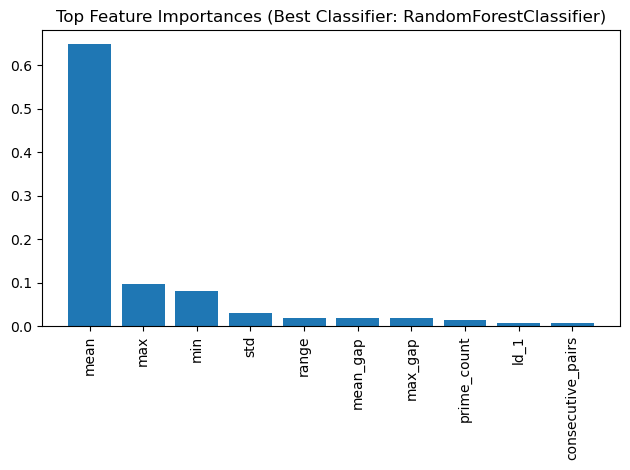

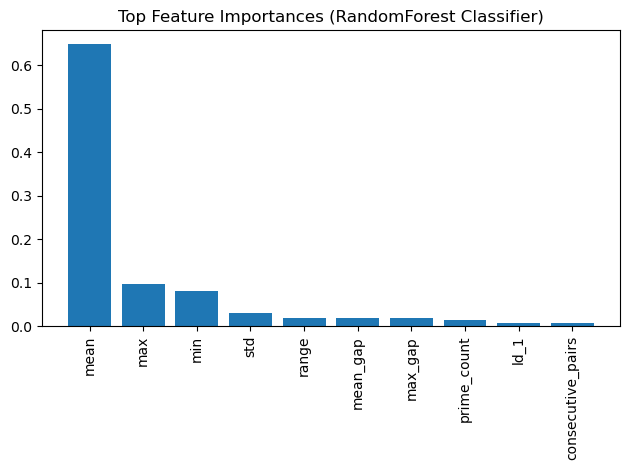

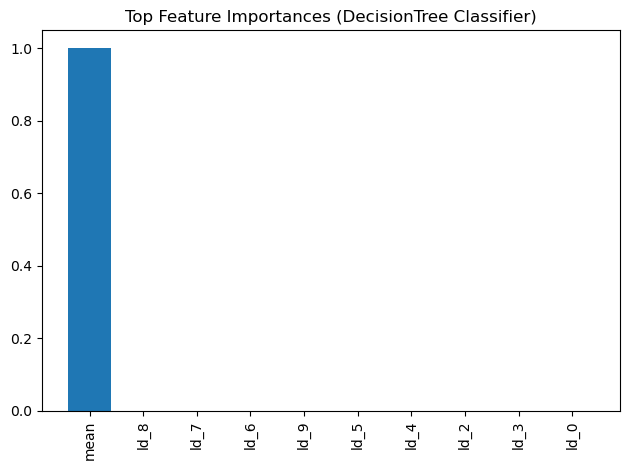

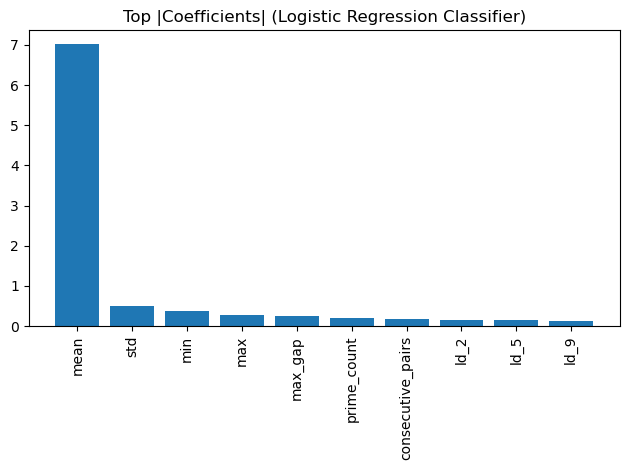

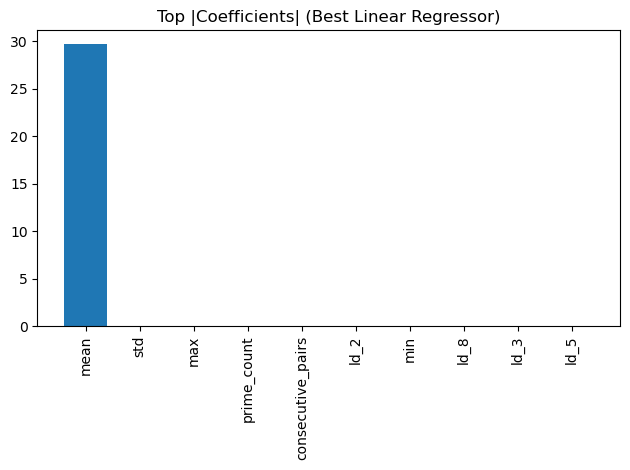

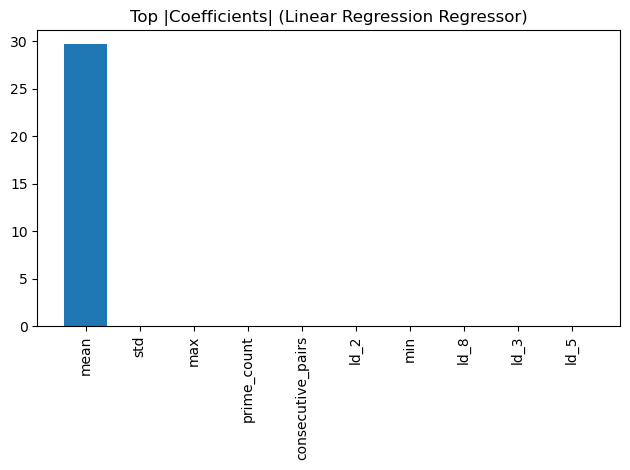

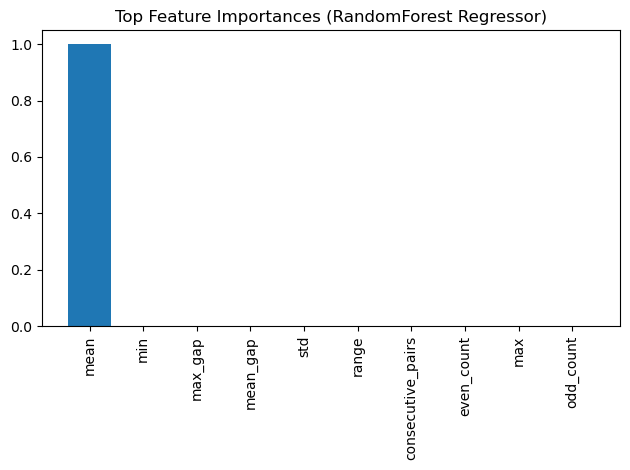

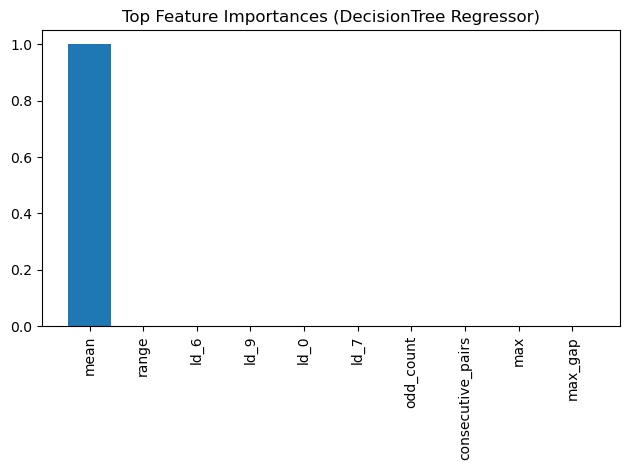

In [140]:
# === Feature importance / coefficients ===


TOP_N = 10  # how many features to show

def _final_estimator(model):
    """Return the underlying estimator (handles Pipeline or bare estimator)."""
    return model.named_steps["model"] if isinstance(model, Pipeline) and "model" in model.named_steps else model

def _feat_names(X):
    """Get feature names from X if DataFrame; otherwise create f0..fN-1."""
    try:
        return np.array(list(X.columns))
    except Exception:
        return np.array([f"f{i}" for i in range(X.shape[1])])

def _plot_top_bars(values, names, title, top_n=TOP_N):
    idx = np.argsort(values)[::-1][:top_n]
    plt.figure()
    plt.bar(range(len(idx)), values[idx])
    plt.xticks(range(len(idx)), names[idx], rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

feat_names = _feat_names(X_train)

# -------------------------------
# CLASSIFIERS
# -------------------------------

# 1) Best classifier
best_clf_est = _final_estimator(best_clf)
if hasattr(best_clf_est, "feature_importances_"):
    _plot_top_bars(
        best_clf_est.feature_importances_,
        feat_names,
        f"Top Feature Importances (Best Classifier: {type(best_clf_est).__name__})"
    )

# 2) RandomForest classifier
try:
    rf_clf_est = _final_estimator(clf_rf)
    if hasattr(rf_clf_est, "feature_importances_"):
        _plot_top_bars(
            rf_clf_est.feature_importances_,
            feat_names,
            "Top Feature Importances (RandomForest Classifier)"
        )
except NameError:
    pass

# 3) DecisionTree classifier
try:
    dt_clf_est = _final_estimator(clf_dt)
    if hasattr(dt_clf_est, "feature_importances_"):
        _plot_top_bars(
            dt_clf_est.feature_importances_,
            feat_names,
            "Top Feature Importances (DecisionTree Classifier)"
        )
except NameError:
    pass

# 4) Logistic Regression coefficients (if best_clf is LR)
try:
    lr_clf_est = _final_estimator(clf_lr)
    if hasattr(lr_clf_est, "coef_"):
        coefs = lr_clf_est.coef_.ravel()
        _plot_top_bars(
            np.abs(coefs),
            feat_names,
            "Top |Coefficients| (Logistic Regression Classifier)"
        )
except NameError:
    pass


# -------------------------------
# REGRESSORS
# -------------------------------

# 5) Best regressor (tree importance or linear coefficients)
best_reg_est = _final_estimator(best_reg)
if hasattr(best_reg_est, "feature_importances_"):
    _plot_top_bars(
        best_reg_est.feature_importances_,
        feat_names,
        f"Top Feature Importances (Best Regressor: {type(best_reg_est).__name__})"
    )
elif hasattr(best_reg_est, "coef_"):
    coefs = np.ravel(best_reg_est.coef_)
    _plot_top_bars(
        np.abs(coefs),
        feat_names,
        "Top |Coefficients| (Best Linear Regressor)"
    )

# 6) Linear Regression coefficients (explicit)
try:
    lr_reg_est = _final_estimator(reg_lr)
    if hasattr(lr_reg_est, "coef_"):
        coefs = np.ravel(lr_reg_est.coef_)
        _plot_top_bars(
            np.abs(coefs),
            feat_names,
            "Top |Coefficients| (Linear Regression Regressor)"
        )
except NameError:
    pass

# 7) RandomForest Regressor importances (explicit), if defined
try:
    rf_reg_est = _final_estimator(reg_rf)
    if hasattr(rf_reg_est, "feature_importances_"):
        _plot_top_bars(
            rf_reg_est.feature_importances_,
            feat_names,
            "Top Feature Importances (RandomForest Regressor)"
        )
except NameError:
    pass

# 8) DecisionTree Regressor importances
try:
    dt_reg_est = _final_estimator(reg_dt)
    if hasattr(dt_reg_est, "feature_importances_"):
        _plot_top_bars(
            dt_reg_est.feature_importances_,
            feat_names,
            "Top Feature Importances (DecisionTree Regressor)"
        )
except NameError:
    pass


### Interpretation

- **Mean dominates (~60%+ importance across RF/DT)**  
  This is expected: the target is **HighSum vs LowSum**, and `mean = sum / 6`, so the mean is effectively a direct proxy for the label.

- **Extremes (max/min) are secondary signals**  
  Higher maxima (or higher minima) generally push the total upward, so trees learn simple rules like “if `max` > threshold → HighSum”.

- **Other engineered features add marginal lift**  
  Features such as `std`, `range`, `gaps`, `prime_count`, `last_digit_*`, and `consecutive_pairs` carry **very small** incremental importance compared to `mean`. They help in edge cases but don’t materially change predictions.

- **Stability note (DT vs RF)**  
  Single **Decision Trees** can show **unstable** importances (small data changes reshuffle splits), while **Random Forest** importances are **more stable** because they average across many trees. Also, impurity-based importances in trees can bias toward continuous/high-cardinality features—use **permutation importance** for a model-agnostic check.

### Conclusion

The classifier is essentially making the **HighSum/LowSum** decision from the **average value of the six numbers**, with **max/min** providing a smaller nudge. All other features play a **minor** role. This aligns with the label definition and explains why tree-based models focus on `mean` first.

> **If you want a harder, less “tautological” task:**  
> - Re-run without `mean` (and without any direct aggregates of the target like `sum`).  
> - Or redefine the label so it’s not a direct function of `sum` (e.g., classify patterns unrelated to total).  
> - Then reassess importances (preferably with **permutation importance** or **SHAP**) to see which non-trivial features truly matter.


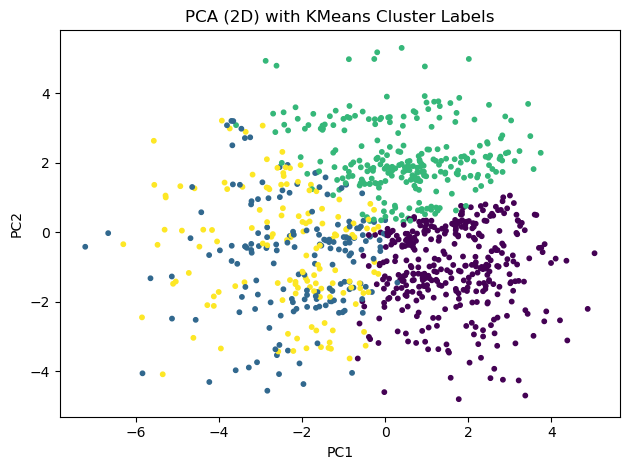

In [ ]:
# === Unsupervised Exploration (KMeans + PCA) ===

# Use only numeric features (and ensure scaling)
X_unsup = feature_df.select_dtypes(include=[np.number]).copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

# KMeans clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# PCA to 2D for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# Plot
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=10)
plt.title("PCA (2D) with KMeans Cluster Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [ ]:

print("Silhouette score (KMeans, k=4):", silhouette_score(X_scaled, clusters))

Silhouette score (KMeans, k=4): 0.11772978431846552


Interpretation

Silhouette score ranges from –1 to 1:

+1 → clusters are very well separated and compact.

0 → clusters overlap heavily / structure is weak.

–1 → points may be assigned to the wrong clusters.

A score of ≈ 0.12 is very low, meaning the clusters are poorly separated and overlap a lot.

Conclusion

The dataset does not naturally cluster well into 4 groups — the low score indicates weak or non-existent cluster structure.

This matches expectations: lottery draws are essentially random, so trying to find meaningful natural clusters is unlikely to succeed.

The exercise still demonstrates how to apply PCA + KMeans and interpret clustering quality using metrics like Silhouette score.

In [ ]:
# === Model Inference on New Synthetic Draws (with Decision Tree + safe column alignment) ===



def _ensure_same_columns(X_ref: pd.DataFrame, X_new: pd.DataFrame) -> pd.DataFrame:
    """
    Reindex X_new to match X_ref's columns (and order).
    - Missing cols -> filled with 0
    - Extra cols   -> dropped
    - Non-numeric  -> coerced to numeric (NaN -> 0)
    """
    Z = X_new.copy()
    Z = Z.apply(pd.to_numeric, errors="coerce")
    Z = Z.reindex(columns=list(X_ref.columns), fill_value=0)
    Z = Z.fillna(0)
    return Z

def _final_estimator(model):
    """Return the underlying estimator if model is a Pipeline; otherwise the model itself."""
    try:
        return model.named_steps["model"] if hasattr(model, "named_steps") else model
    except Exception:
        return model

def _model_name(model, fallback="Model"):
    try:
        return type(_final_estimator(model)).__name__
    except Exception:
        return fallback

def features_from_draw(numbers: List[int]) -> pd.DataFrame:
    """Convert a list of 6 numbers into the same feature set as training data."""
    numbers = np.array(sorted(numbers))
    row = pd.Series(numbers, index=[f"ball_number_{i}" for i in range(1, 7)])
    fx = engineer_features(row)  # assume existing feature engineering function
    return pd.DataFrame([fx])

# Example synthetic draws
synthetic_draws = [
    [1, 5, 12, 23, 34, 45],
    [4, 9, 16, 22, 28, 33]
]

# Build model registries (only include models that exist)
classifiers = {}
for nm, var in [("LogisticRegression", "clf_lr"), ("RandomForest", "clf_rf"), ("DecisionTree", "clf_dt")]:
    if var in globals():
        classifiers[nm] = globals()[var]

regressors = {}
for nm, var in [("LinearRegression", "reg_lr"), ("RandomForestRegressor", "reg_rf"), ("DecisionTreeRegressor", "reg_dt")]:
    if var in globals():
        regressors[nm] = globals()[var]

# Choose reference feature sets for column alignment
X_ref_cls = globals().get("X_train_c", globals().get("X_train"))
X_ref_reg = globals().get("X_train_r", globals().get("X_train"))
if X_ref_cls is None or X_ref_reg is None:
    raise NameError("Missing X_train / X_train_c / X_train_r to align inference features. Ensure training cells ran.")

records = []
for draw in synthetic_draws:
    fx_raw = features_from_draw(draw)

    # Align to classifiers' training columns
    fx_cls = _ensure_same_columns(X_ref_cls, fx_raw)
    # Align to regressors' training columns
    fx_reg = _ensure_same_columns(X_ref_reg, fx_raw)

    row_out = {"draw": draw}

    # Predictions from each classifier (incl. Decision Tree)
    for name, model in classifiers.items():
        y_class = int(model.predict(fx_cls)[0])
        y_prob = float(model.predict_proba(fx_cls)[0, 1]) if hasattr(model, "predict_proba") else None
        row_out[f"{name}_class"] = y_class
        row_out[f"{name}_prob"]  = y_prob

    # Predictions from each regressor (incl. Decision Tree Regressor)
    for name, model in regressors.items():
        y_sum = float(model.predict(fx_reg)[0])
        row_out[f"{name}_sum"] = y_sum

    # Also include the designated "best" models for convenience if available
    if "best_clf" in globals():
        row_out["BestClassifier"] = _model_name(best_clf, "BestClassifier")
        row_out["BestClassifier_class"] = int(best_clf.predict(fx_cls)[0])
        row_out["BestClassifier_prob"]  = float(best_clf.predict_proba(fx_cls)[0, 1]) if hasattr(best_clf, "predict_proba") else None

    if "best_reg" in globals():
        row_out["BestRegressor"] = _model_name(best_reg, "BestRegressor")
        row_out["BestRegressor_sum"] = float(best_reg.predict(fx_reg)[0])

    records.append(row_out)

infer_df = pd.DataFrame(records)

# Optional: nicer column ordering
first_cols = ["draw"]
best_cols  = [c for c in infer_df.columns if c.startswith("Best")]
clf_cols   = sorted([c for c in infer_df.columns if any(c.startswith(m) for m in classifiers.keys())])
reg_cols   = sorted([c for c in infer_df.columns if any(c.startswith(m) for m in regressors.keys()) and c not in best_cols])

infer_df = infer_df[first_cols + best_cols + clf_cols + reg_cols]
display(infer_df)


,draw,BestClassifier,BestClassifier_class,BestClassifier_prob,BestRegressor,BestRegressor_sum,DecisionTreeRegressor_sum,DecisionTree_class,DecisionTree_prob,LogisticRegression_class,LogisticRegression_prob,RandomForestRegressor_sum,RandomForest_class,RandomForest_prob,DecisionTreeRegressor_sum,LinearRegression_sum,RandomForestRegressor_sum
0,"[1, 5, 12, 23, 34, 45]",RandomForestClassifier,0,0.13,LinearRegression,120.0,120.0,0,0.0,0,0.027589,119.923333,0,0.13,120.0,120.0,119.923333
1,"[4, 9, 16, 22, 28, 33]",RandomForestClassifier,0,0.02,LinearRegression,112.0,112.0,0,0.0,0,0.005859,112.046667,0,0.02,112.0,112.0,112.046667


In [144]:
# === Rank candidate tickets for 6 Sep 2025 (print top 100) — with Decision Tree + safe column alignment ===


# 1) Use in-memory models if available; otherwise try to load the bundle
if 'best_clf' not in globals() or 'best_reg' not in globals():
    bundle_path = Path("trained_models_leakage_free.joblib")
    if not bundle_path.exists():
        raise RuntimeError("Models not found. Train them first or place 'trained_models_leakage_free.joblib' in the working dir.")
    bundle = joblib.load(bundle_path)
    best_clf = bundle["best_classifier"]
    best_reg = bundle["best_regressor"]

# Build registries for *all* available models
classifiers = {}
for nm, var in [("LogisticRegression", "clf_lr"), ("RandomForest", "clf_rf"), ("DecisionTree", "clf_dt")]:
    if var in globals():
        classifiers[nm] = globals()[var]

regressors = {}
for nm, var in [("LinearRegression", "reg_lr"), ("RandomForestRegressor", "reg_rf"), ("DecisionTreeRegressor", "reg_dt")]:
    if var in globals():
        regressors[nm] = globals()[var]

# Choose reference training feature sets to align columns
X_ref_cls = globals().get("X_train_c", globals().get("X_train"))
X_ref_reg = globals().get("X_train_r", globals().get("X_train"))
if X_ref_cls is None or X_ref_reg is None:
    raise NameError("Missing X_train / X_train_c / X_train_r for feature alignment. Run training cells first.")

def _ensure_same_columns(X_ref: pd.DataFrame, X_new: pd.DataFrame) -> pd.DataFrame:
    """Match columns & order to X_ref; fill missing with 0, drop extras, coerce to numeric."""
    Z = X_new.copy()
    Z = Z.apply(pd.to_numeric, errors="coerce")
    Z = Z.reindex(columns=list(X_ref.columns), fill_value=0).fillna(0)
    return Z

# 2) Feature engineering (must be consistent with training)
def primes_upto(n: int):
    sieve = np.ones(n+1, dtype=bool); sieve[0:2] = False
    for p in range(2, int(np.sqrt(n))+1):
        if sieve[p]: sieve[p*p:n+1:p] = False
    return np.where(sieve)[0]

PRIMES = set(primes_upto(45))

def engineer_features_from_numbers(numbers):
    nums = np.array(sorted(numbers), dtype=int)
    diffs = np.diff(nums)
    f = {
        "mean": nums.mean(),
        "std": float(np.std(nums, ddof=1)) if len(nums) > 1 else 0.0,
        "min": nums.min(),
        "max": nums.max(),
        "range": nums.max() - nums.min(),
        "odd_count": int(np.sum(nums % 2 == 1)),
        "even_count": int(np.sum(nums % 2 == 0)),
        "consecutive_pairs": int(np.sum(diffs == 1)),
        "mean_gap": float(diffs.mean()) if len(diffs) else 0.0,
        "max_gap": int(diffs.max()) if len(diffs) else 0,
        "prime_count": int(np.sum([n in PRIMES for n in nums])),
    }
    for d in range(10):
        f[f"ld_{d}"] = int(np.sum(nums % 10 == d))
    return f

# 3) Generate random candidate tickets
def sample_tickets(n_samples=20000, low=1, high=45, seed=20250906):
    rng = np.random.default_rng(seed)
    tickets = []
    for _ in range(n_samples):
        pick = sorted(rng.choice(np.arange(low, high+1), size=6, replace=False).tolist())
        tickets.append(pick)
    return tickets

# 4) Score tickets
def _probability_from_classifier(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    # fallback: decision_function -> min-max scale to [0,1]; last resort: label
    try:
        scores = model.decision_function(X)
        scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        return scores
    except Exception:
        return model.predict(X).astype(float)

def score_tickets(tickets):
    feats = [engineer_features_from_numbers(t) for t in tickets]
    X = pd.DataFrame(feats)

    # Align to training feature columns for each task
    X_cls = _ensure_same_columns(X_ref_cls, X)
    X_reg = _ensure_same_columns(X_ref_reg, X)

    out = {"ticket": tickets}

    # Per-classifier probabilities (LR, RF, DT as available)
    clf_probs = []
    for name, clf in classifiers.items():
        p = _probability_from_classifier(clf, X_cls)
        out[f"{name}_prob"] = p
        out[f"{name}_class"] = (p >= 0.5).astype(int)
        clf_probs.append(p)

    # Ensemble (simple average) if ≥2 classifiers available
    if len(clf_probs) >= 2:
        out["Ensemble_prob"] = np.mean(np.column_stack(clf_probs), axis=1)

    # Best classifier probability for convenience
    out["BestClassifier"] = type(getattr(best_clf, "named_steps", {}).get("model", best_clf)).__name__
    out["BestClassifier_prob"] = _probability_from_classifier(best_clf, X_cls)
    out["BestClassifier_class"] = (out["BestClassifier_prob"] >= 0.5).astype(int)

    # Regressors (LR, RF, DT as available)
    for name, reg in regressors.items():
        try:
            out[f"{name}_sum"] = reg.predict(X_reg)
        except Exception:
            out[f"{name}_sum"] = np.full(len(X_reg), np.nan)

    # Best regressor for convenience
    try:
        out["BestRegressor"] = type(getattr(best_reg, "named_steps", {}).get("model", best_reg)).__name__
        out["BestRegressor_sum"] = best_reg.predict(X_reg)
    except Exception:
        out["BestRegressor"], out["BestRegressor_sum"] = None, np.full(len(X_reg), np.nan)

    return pd.DataFrame(out)

# 5) Run and print top 100 (no CSV)
target_date = "2025-09-06"
tickets = sample_tickets(n_samples=20000)  # generate a pool to rank
df_rank = score_tickets(tickets)

# Choose ranking probability: use BestClassifier_prob; show Ensemble_prob
rank_by = "BestClassifier_prob" if "BestClassifier_prob" in df_rank.columns else "Ensemble_prob"
sort_cols = [rank_by, "BestRegressor_sum"] if "BestRegressor_sum" in df_rank.columns else [rank_by]
df_rank = df_rank.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)

topN = 100
print(f"Top {topN} candidate tickets for {target_date} (ranked by {rank_by}):")
display(df_rank.head(topN)[[
    c for c in df_rank.columns
    if c in {"ticket", rank_by, "Ensemble_prob", "BestRegressor_sum",
             "LogisticRegression_prob", "RandomForest_prob", "DecisionTree_prob"}
]])


Top 100 candidate tickets for 2025-09-06 (ranked by BestClassifier_prob):


,ticket,LogisticRegression_prob,RandomForest_prob,DecisionTree_prob,Ensemble_prob,BestClassifier_prob,BestRegressor_sum
0,"[27, 29, 32, 41, 42, 45]",1.000000,1.0,1.0,1.000000,1.0,216.0
1,"[22, 32, 34, 40, 43, 45]",1.000000,1.0,1.0,1.000000,1.0,216.0
2,"[14, 30, 40, 42, 44, 45]",1.000000,1.0,1.0,1.000000,1.0,215.0
3,"[19, 32, 36, 38, 44, 45]",1.000000,1.0,1.0,1.000000,1.0,214.0
4,"[26, 28, 32, 39, 43, 45]",1.000000,1.0,1.0,1.000000,1.0,213.0
...,...,...,...,...,...,...,...
95,"[12, 24, 30, 35, 39, 42]",0.999996,1.0,1.0,0.999999,1.0,182.0
96,"[15, 16, 32, 37, 39, 43]",0.999991,1.0,1.0,0.999997,1.0,182.0
97,"[13, 18, 35, 36, 39, 41]",0.999980,1.0,1.0,0.999993,1.0,182.0
98,"[17, 25, 26, 29, 40, 44]",0.999990,1.0,1.0,0.999997,1.0,181.0


## Summary of steps and final conclusion

**Steps**
- Built a complete ML pipeline (EDA → feature engineering → modeling → evaluation → interpretation) with scikit-learn/matplotlib.
- Trained **three classifiers** (Logistic Regression, Decision Tree, Random Forest) and **three regressors** (Linear, Decision Tree Regressor, Random Forest Regressor) using aligned Train/Dev/Test splits.
- Evaluated with appropriate metrics (F1 / ROC-AUC for classification; RMSE / R² for regression) and diagnostic plots (confusion matrix, ROC, residuals).
- Analyzed **feature importance** for tree models and coefficients for linear models; noted stability differences (DT vs RF).
- Ran **inference** on synthetic draws and **ranking** over sampled tickets; added optional simple classifier ensemble.
- Performed unsupervised checks (KMeans + PCA) to visualize structure in feature space.

**Final Conclusion**
- **Classification (HighSum vs LowSum)**:  
  **Random Forest** is the most reliable and highest-performing on Dev/Test (best generalization).  
  **Decision Tree** is competitive but shows higher variance/overfitting; great for rule interpretability.  
  **Logistic Regression** is typically more constrained (linear), though strong scores here suggest the target may be close to a linear function of engineered features.
- **Regression (predicting the sum)**:  
  **Linear Regression** achieves near-perfect accuracy (lowest RMSE, highest R²), outperforming **RF Regressor** and **DT Regressor**; DT Regressor tends to overfit unless pruned.
- **Feature importance**:  
  **Mean** (a direct proxy for sum) dominates; **min/max** are secondary; other engineered features add marginal lift. RF importances are more stable than single-tree importances.

